# Expressing Mixtral-8x7B

This notebook writes Mixtral-8x7B, the sparse mixture-of-experts model released by Mistral AI, as one expression and draws it part by part. It then writes the number formats of the released implementation onto the expression, derives the pass that generates new tokens from a cache of keys and values, and writes an interactive page holding the four forms.

*Written by Claude Opus 5.5 (1M context) at reasoning effort 40, 2026-09-27.*

In [1]:
import dataclasses

from IPython.display import Markdown, display

import advanced_axis_dynamics.algebra.slide_causal_reads_backwards as slide_causal_reads_backwards

import notebooks.classic.cached_mixtral_8x7b as cached_mixtral_8x7b
import notebooks.classic.mixtral_8x7b as mixtral_8x7b
import notebooks.classic.mixtral_8x7b_page_variants as mixtral_8x7b_page_variants
import notebooks.classic.quantised_mixtral_8x7b as quantised_mixtral_8x7b
import notebooks.display.notebook_diagrams as notebook_diagrams
import notebooks.display.sota_figures as figures
import notebooks.website.website_output as website_output

DIAGRAMS = figures.DiagramSettings(
    mode=figures.DiagramMode.INLINE,
    dark_mode=notebook_diagrams.ColorMode.LIGHT,
    axis_sizes=figures.AxisSizes.SUBSCRIPT,
    assigned_sizes=cached_mixtral_8x7b.RELEASED_SIZES,
    advanced_display=figures.AdvancedDisplay.LEGEND,
    operator_explanations=mixtral_8x7b.OPERATOR_EXPLANATIONS,
    operator_roles=mixtral_8x7b.OPERATOR_ROLES,
    operator_references=mixtral_8x7b.OPERATOR_REFERENCES,
    reindexing_explanations=mixtral_8x7b.REINDEXING_EXPLANATIONS,
    title='Mixtral-8x7B')
QUANTISED_DIAGRAMS = dataclasses.replace(DIAGRAMS, clean_quantisation_labels=False)

## Reading the Figures

A figure is a neural circuit diagram of one expression. Every wire is an array, and the label on a wire names one axis of the array, with the size bound by the released configuration written as a subscript. A wire passes through an operator when the operator is computed once for every index of that axis, and a wire ends at an operator when the operator consumes the axis. A block is a titled box around a part of the expression. A block whose repetition is greater than one is a loop, drawn with the repetition at its left bracket. A named box, such as `RoPE`, stands for a block drawn as one operator, and its body is drawn beside the first figure that holds it. A circle holding a wave is the table of a rotary embedding. A pentagon is a view, which reads its operand at positions given by an affine map of the positions of its result. The legend beside each figure lists every axis with its size and a name for it in code.

| axis | size | what it indexes |
| --- | --- | --- |
| `x` | set by the input | the token positions of the prompt |
| `w` | the size of `x` | the tokens read by a query, counted back from its own |
| `m` | 4096 | the model width, `dim` in the released code |
| `h'`, `g` | 8, 4 | the key-value heads, and the query heads that share one key-value head |
| `d`, `t` | 128, 64 | the width of one head, and the pairs of its channels turned by the rotary embedding |
| `n`, $\lvert k \rvert$ | 8, 2 | the experts, and the experts read by each token |
| `f` | 14336 | the inner width of an expert, `hidden_dim` in the released code |
| $\bar{v}$ | 32000 | the vocabulary |

## The Attention Groups Its 32 Query Heads by Key-Value Head

Each token is projected into 32 queries and into 8 keys and 8 values of $d = 128$ channels ([`transformer_layers.py` L51-L54](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L51-L54)). The released code repeats every key and every value four times with `repeat_interleave`, so that query head $i$ attends with key-value head $\lfloor i / 4 \rfloor$ ([L16-L19](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L16-L19), [L83-L84](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L83-L84)). The query projection $W^{Q}$ of the expression produces the 32 queries of a token on two axes, as $h' = 8$ groups of $g = 4$ heads. Query head $\lvert g \rvert i_{h'} + i_g$ of the released code is head $i_g$ of group $i_{h'}$. The released code projects onto 32 heads and then reshapes the result. $W^{Q}$ holds its weight inside the operator, so a projection followed by a grouping of its heads is the projection whose weight rows are grouped the same way, and the expression writes the grouping into $W^{Q}$. The keys and the values carry the group axis $h'$ alone. Every query head of a group therefore scores against the same key-value head, and nothing is repeated.

The queries and the keys are turned by the rotary embedding before the scores ([`rope.py` L13-L23](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/rope.py#L13-L23)). Each pair of adjacent channels is read as one complex number and multiplied by $e^{\mathrm{i}\, i_x\, \theta[i_t]}$, with $\theta[i_t] = \beta^{-i_t / \lvert t \rvert}$ and $\beta = 10^6$ ([`config.json` L21](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L21)). The score of a query at position $p$ against a key at position $q$ then depends on the positions through $p - q$ alone. The rotary embedding is the box `RoPE`, written over the vector of one head of one token and computed once per head. In its body the table draws as the circle holding a wave, and the two hexagons around it read the channels as complex numbers and write them back.

## The Causal Mask Reads Each Token and the Tokens Before It

The released configuration sets no sliding window ([`config.json` L23](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L23)), so every token attends to itself and to every token before it. The expression reads the keys and the values through the view named Mask, whose slot $i_w$ of token $i_x$ holds token $i_x - i_w$. A slot before the first token names a negative position. Reading an array outside its axis gives the universal unit, and the softmax and the weighted sum treat that unit as absent. The slot axis therefore leaves the view as `w|x`, a sparse axis whose live positions are those with $i_x - i_w \geq 0$. In a prompt of four tokens, token $i$ reads the slots 0 to $i$. The expression holds no mask operator, and the released code states the same restriction with the causal masks handed to the attention kernel ([`cache.py` L236-L254](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L236-L254)).

## The Mask Is Drawn at the Copy That Feeds the Keys and the Values

The key projection, the value projection and the rotary embedding each compute the same function at every token. Reading their results at token $i_x - i_w$ therefore gives the same values as reading their operand at token $i_x - i_w$ and computing afterwards. The figures draw every causal read as far back as it can move, at the copy of the normalised hidden state that feeds the queries, the keys and the values. The expression drawn with its causal reads moved back to that copy is called its CausalSlide. In the CausalSlide one view reads the state for the keys and the values together, and $W^{K}$, $W^{V}$ and the rotary embedding of the keys are drawn over the tokens and the slots. The box turning the keys reads the table of turns through the same view, so the key at slot $i_w$ of token $i_x$ is turned by the angle of position $i_x - i_w$. The two boxes therefore hold two bodies, both drawn beside the figure. The position of a causal read is also a place where a cache can stand, which the section on the cached pass uses.

The attention of one layer in the CausalSlide: the mask reads the normalised state at the copy, W^K, W^V and the rotary embedding of the keys run over the tokens and the slots, and the two bodies of the box RoPE are drawn beside the figure, the second reading the table of turns through the mask.


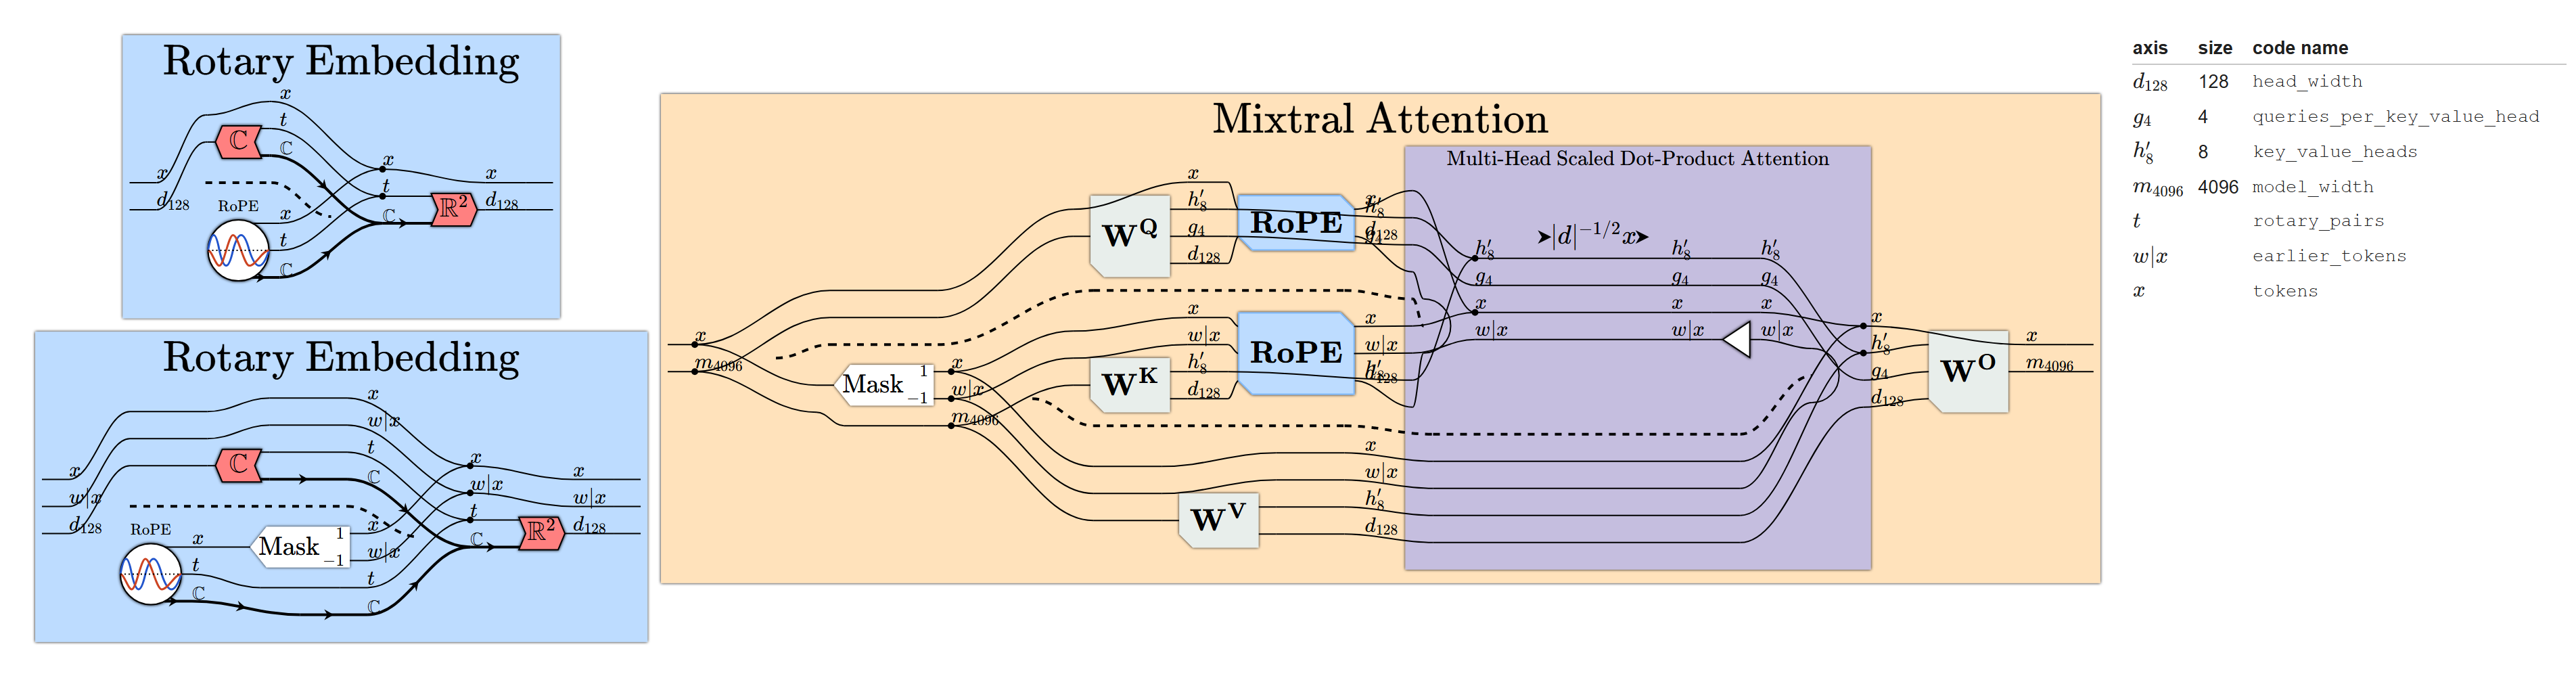

In [2]:
await figures.show(
    slide_causal_reads_backwards.slide_causal_reads_backwards(mixtral_8x7b.attention()),
    'The attention of one layer in the CausalSlide: the mask reads the normalised state at '
    'the copy, W^K, W^V and the rotary embedding of the keys run over the tokens and the '
    'slots, and the two bodies of the box RoPE are drawn beside the figure, the second '
    'reading the table of turns through the mask.',
    width=1400, sub_blocks=figures.SubBlocks.EVERY_BODY, settings=DIAGRAMS)

## The Router Sends Each Token to Two of Its Eight Experts

The gate projection $W^{g}$ gives every token one score per expert, the top-2 keeps the two highest scores, and the softmax of the two kept scores gives the weight of each chosen expert ([`moe.py` L25-L27](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/moe.py#L25-L27)). Each expert is a SwiGLU, $W_2(\mathrm{SiLU}(W_1 x) \odot W_3 x)$ with an inner width of 14336 ([`transformer_layers.py` L96-L106](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L96-L106)). The output is the sum of the outputs of the two chosen experts under their weights ([`moe.py` L28-L32](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/moe.py#L28-L32)).

The selection returns its scores on the sparse axis `k/n`, whose live positions are the two chosen experts, and the softmax that follows normalises over them alone. Each expert projection is one linear map that produces the expert axis, so its weight holds all eight experts. Composition aligns the expert axis with `k/n`, so the projection is computed for the two chosen experts alone. The second projection $W_2$ produces the expert axis a second time, and the view named Diagonal keeps the output of the expert chosen by each slot. The sum over the two experts is one contraction of the weights against the expert outputs over `k/n`.

The sparse mixture of experts: the router scoring the eight experts and keeping two, the SwiGLU of the chosen experts with the diagonal after the second projection, and the weighted sum over the two.


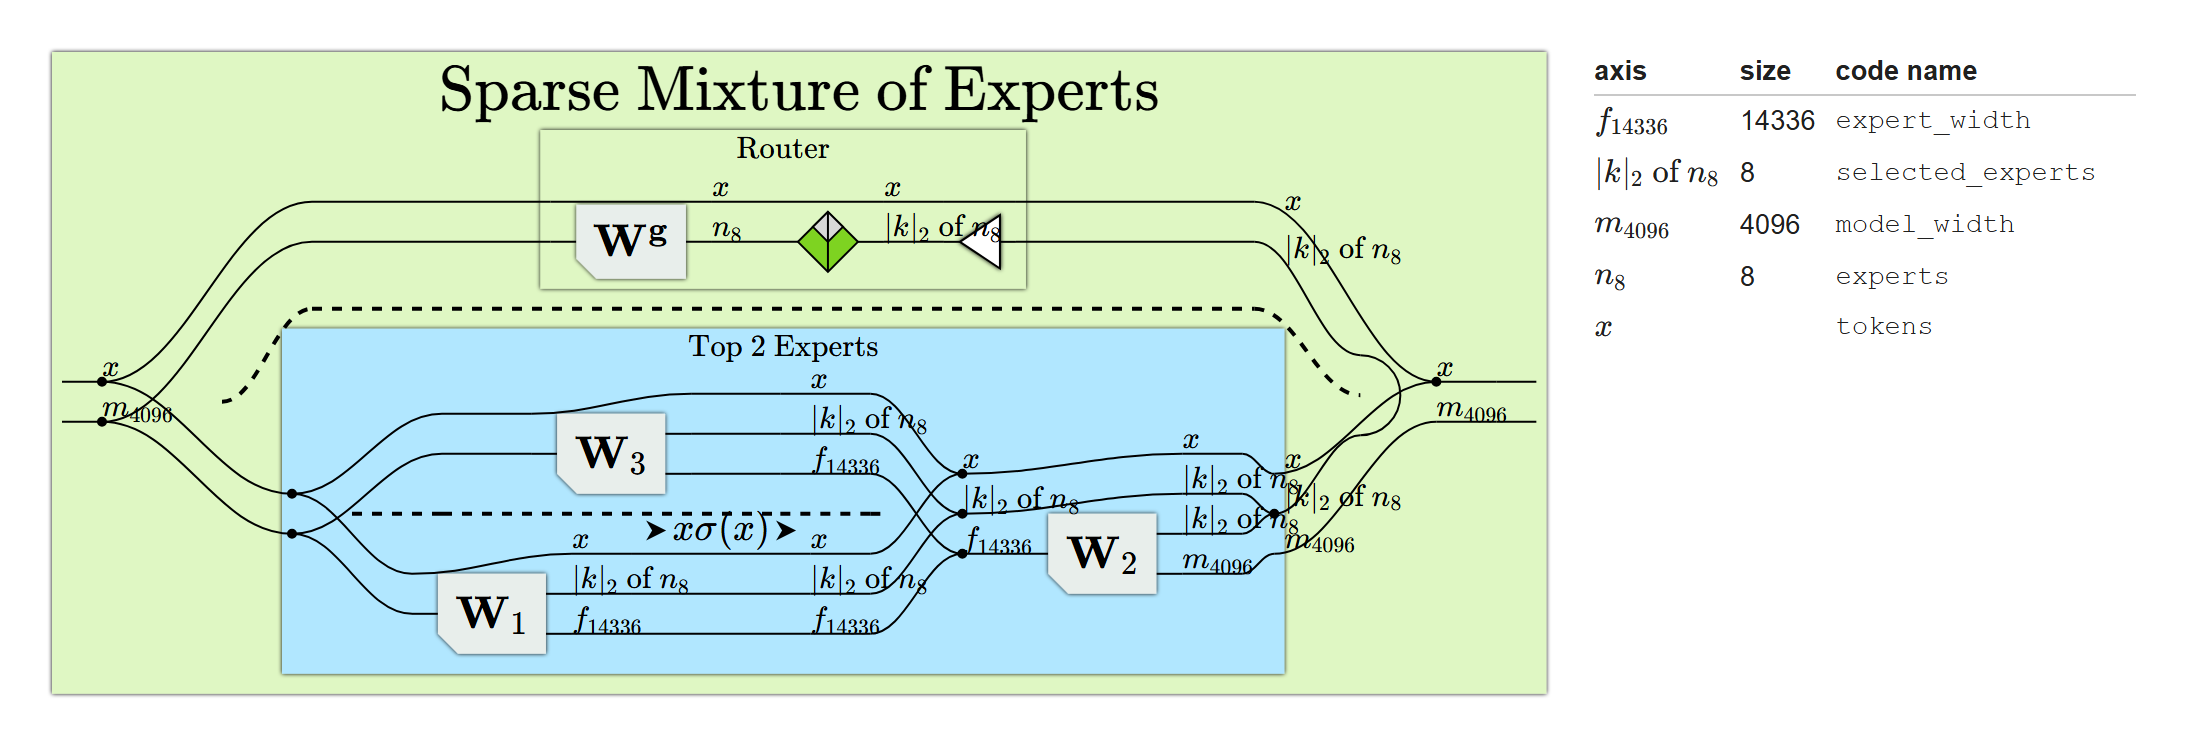

In [3]:
await figures.show(
    mixtral_8x7b.sparse_mixture_of_experts(),
    'The sparse mixture of experts: the router scoring the eight experts and keeping two, '
    'the SwiGLU of the chosen experts with the diagonal after the second projection, and '
    'the weighted sum over the two.',
    width=1300, settings=DIAGRAMS)

## The Decoder Layer Repeats 32 Times

The token identifiers are embedded into vectors of 4096 values ([`transformer.py` L57](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L57)). Each of the 32 layers adds the attention of the RMSNorm of the hidden state to the hidden state, and then adds the mixture of experts of the RMSNorm of the result ([`transformer_layers.py` L165-L168](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L165-L168)). The RMSNorm divides the 4096 values of a token by their root mean square, with $\epsilon = 10^{-5}$ added under the root, and multiplies each by a learned weight ([L109-L120](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L109-L120)). A final RMSNorm and the output projection give one score per token of the vocabulary ([`transformer.py` L78-L79](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L78-L79)). The softmax of the scores is the probability of the next token. The released forward pass returns the scores, and the sampler takes their softmax ([`generate.py` L151-L153](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L151-L153)).

Mixtral-8x7B in the CausalSlide: the embedding, one decoder layer repeated N times, and the output projection, with the bodies of the boxes left out. The second row starts at the residual connection around the mixture of experts.


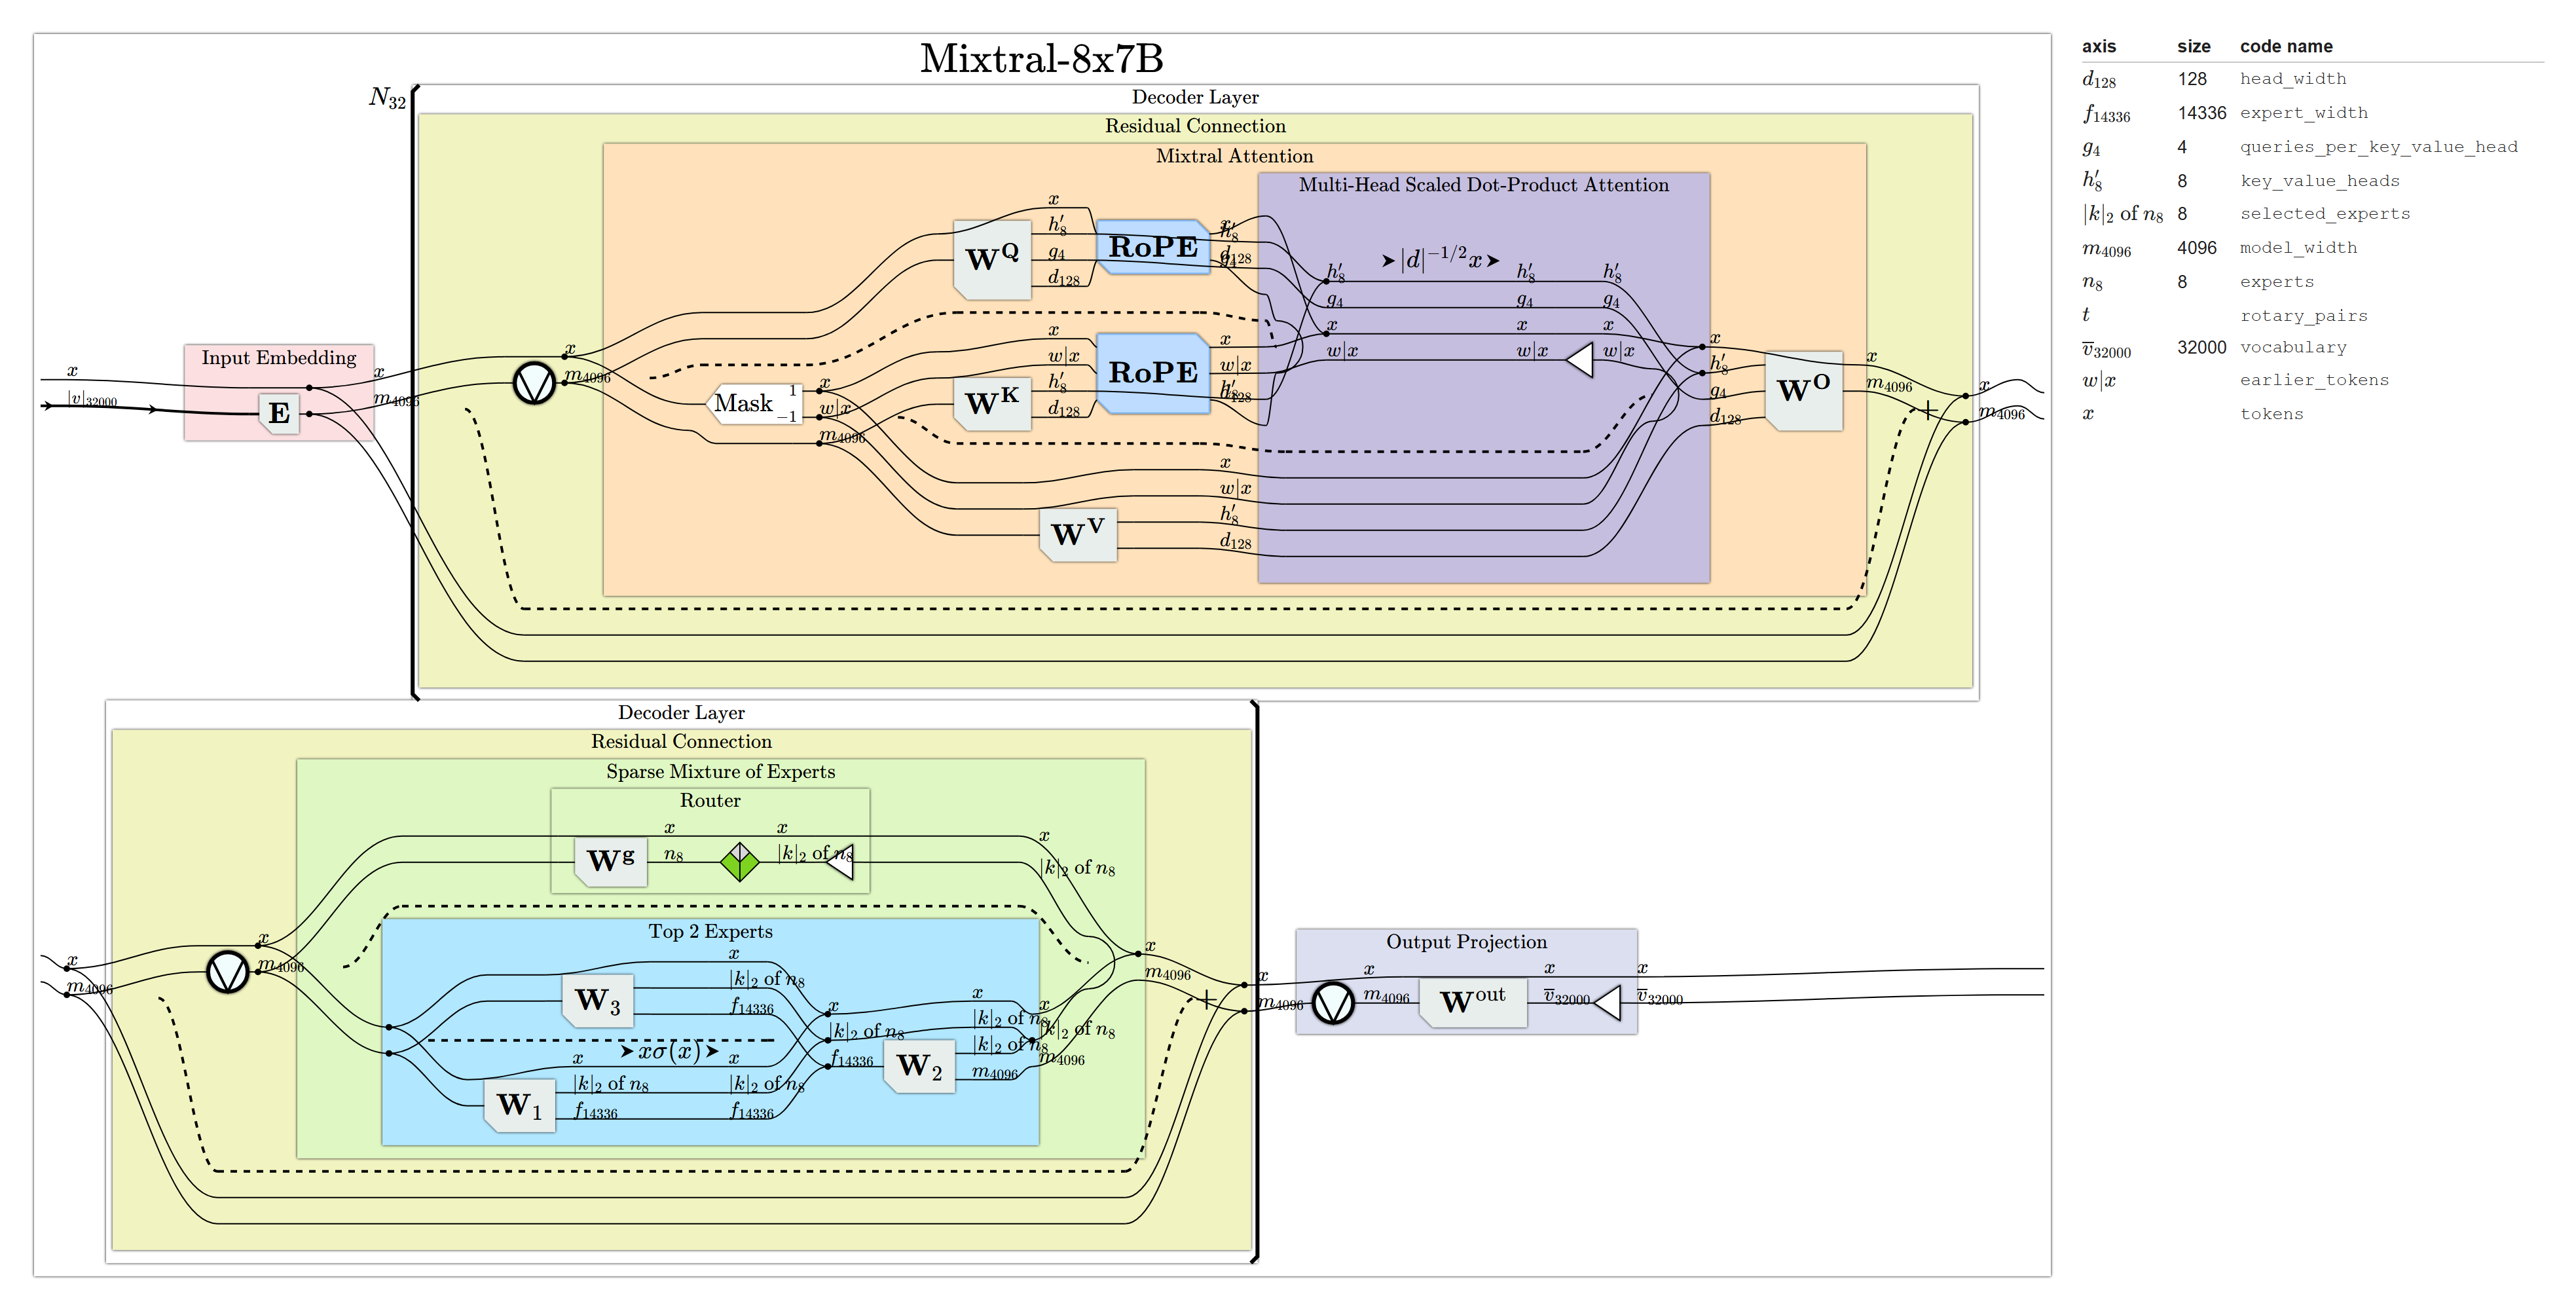

In [4]:
await figures.show(
    quantised_mixtral_8x7b.MIXTRAL_IN_THE_CAUSAL_SLIDE,
    'Mixtral-8x7B in the CausalSlide: the embedding, one decoder layer repeated N times, '
    'and the output projection, with the bodies of the boxes left out. The second row '
    'starts at the residual connection around the mixture of experts.',
    width=1450, sub_blocks=figures.SubBlocks.NO_BODIES, settings=DIAGRAMS)

## The Sizes of the Released Model

The configuration of the released weights binds the sizes ([`config.json` L1-L29](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L1-L29)). The width of a head is not in the file. It is the hidden size divided by the number of heads, $4096 / 32 = 128$. The constants are named in the expression and bound in the text.

| symbol | value | meaning | source |
| --- | --- | --- | --- |
| $N$ | 32 | the number of layers | [`config.json` L16](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L16) |
| $\beta$ | $10^6$ | the base of the rotary frequencies | [`config.json` L21](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L21) |
| $\epsilon$ | $10^{-5}$ | the number added under the root of every RMSNorm | [`config.json` L20](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L20) |
| window | none | the released model attends over the whole context of up to 32768 tokens | [`config.json` L12](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L12), [L23](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L23) |

In [5]:
for name, size in cached_mixtral_8x7b.RELEASED_SIZES.items():
    print(f'{name:>3} = {size}')

  m = 4096
 h' = 8
  g = 4
  d = 128
  f = 14336
  n = 8
  k = 2
  N = 32
  v = 32000


## The Released Implementation Runs in BF16 and Computes in FP32 Where It Upcasts

A quantisation is the number format a value is held in, together with the size of that format in bits. The released checkpoint declares `bfloat16` ([`config.json` L25](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L25)), and every tensor of its shards is stored as BF16, as the headers of [`model-00001-of-00019.safetensors`](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/model-00001-of-00019.safetensors) and [`model-00019-of-00019.safetensors`](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/model-00019-of-00019.safetensors) state. The reference implementation loads the checkpoint with `dtype=None`, which keeps the format of the file ([`transformer.py` L298-L338](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L298-L338), [`main.py` L124](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/main.py#L124)). Every weight and every tensor passed from one module to the next is therefore BF16. The code computes in FP32 in four places: the RMSNorm, the rotary embedding, the attention kernel and the softmax of the router. It returns the logits in FP32.

The expression carries a quantisation on every wire, and a cast wherever an operation requires another quantisation than the one its operand carries. A figure draws the format written by a cast in blue, on the wire after it. A wire in BF16 is labelled 2BF16, because the format packs two values to a word. Four rules decide the quantisation of a wire. A tensor handed from one module to the next is BF16. Arithmetic inside a module that upcasts, and inside a kernel, is FP32. A linear map reads and returns the quantisation of its weight. Everything else computes at the quantisation of its operands. The table lists each quantisation beside the lines of code that state it, read on 2026-09-27.

In [6]:
display(Markdown(quantised_mixtral_8x7b.policy_table()))

| quantisation | what it applies to | lines |
|---|---|---|
| BF16 | every weight: the embedding, the four projections of the attention, the router, the three projections of every expert, the output projection and the gain of every RMSNorm. The checkpoint declares `bfloat16`, every tensor of its shards is `BF16`, and the reference loads the file with `dtype=None`, which keeps the datatype of the file | [config.json L25](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L25), [model-00001-of-00019.safetensors](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/model-00001-of-00019.safetensors), [model-00019-of-00019.safetensors](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/model-00019-of-00019.safetensors), [src/mistral_inference/transformer.py L298-L338](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L298-L338), [src/mistral_inference/main.py L124](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/main.py#L124) |
| BF16 | every tensor passed from one module to the next: the embedding, the result of every projection and every RMSNorm, the residual stream, the turned queries and keys, the values, the output of the attention, of every expert and of the mixture, and the logits before they are returned | [src/mistral_inference/transformer.py L193](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L193), [src/mistral_inference/transformer_layers.py L66-L70](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L66-L70), [src/mistral_inference/transformer_layers.py L165-L168](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L165-L168), [src/mistral_inference/transformer.py L235](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L235) |
| FP32 | the normalisation inside every RMSNorm, rounded to BF16 by the module and multiplied by its BF16 gain in BF16. The expression writes the RMSNorm as one operation reading and returning BF16 | [src/mistral_inference/transformer_layers.py L115-L120](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L115-L120) |
| FP32 | the table of the rotary embedding, held as `complex64`, and the product of each pair of channels with it. The reference reads the queries and the keys into FP32 before pairing their channels and rounds the turned channels to BF16 | [src/mistral_inference/rope.py L6-L10](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/rope.py#L6-L10), [src/mistral_inference/rope.py L18-L23](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/rope.py#L18-L23), [src/mistral_inference/transformer.py L108-L120](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L108-L120) |
| FP32 | the scores of the attention, their softmax and the accumulator of the product with the values inside FlashAttention-2, which reads BF16 queries, keys and values and writes BF16. The probabilities are rounded to BF16 before the product with the values. The expression writes the softmax as one operation, so the kernel's division by the sum of the exponentials, which follows that product, stands before the rounding | [src/mistral_inference/transformer_layers.py L88](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L88), [xformers dispatch.py L86-L130](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/dispatch.py#L86-L130), [xformers flash3.py L116-L124](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/flash3.py#L116-L124), [pyproject.toml L25-L32](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/pyproject.toml#L25-L32), [xformers flash.py L50-L82](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/flash.py#L50-L82), [xformers flash.py L558-L590](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/flash.py#L558-L590), [pytorch CMakeLists.txt L172-L173](https://github.com/pytorch/pytorch/blob/ba56102387ef21a3b04b357e5b183d48f0afefc7/aten/src/ATen/CMakeLists.txt#L172-L173), [flash-attention kernel_traits.h L26](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/kernel_traits.h#L26), [flash-attention flash_fwd_kernel.h L303](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L303), [flash-attention flash_fwd_kernel.h L343-L347](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L343-L347), [flash-attention flash_fwd_kernel.h L367](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L367), [flash-attention flash_fwd_kernel.h L433-L436](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L433-L436) |
| FP32 | the softmax of the two scores the router keeps, taken with `dtype=torch.float` and rounded to BF16 with `.to(inputs.dtype)`. The top-2 selection reads the BF16 scores of the gate projection | [src/mistral_inference/moe.py L25-L27](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/moe.py#L25-L27) |
| BF16 | the SiLU and the product of the two branches of every expert, returned in BF16 by eager PyTorch, and the weighted sum of the two chosen experts, accumulated into a BF16 tensor by the reference | [src/mistral_inference/transformer_layers.py L105-L106](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L105-L106), [src/mistral_inference/moe.py L28-L31](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/moe.py#L28-L31) |
| FP32 | the logits the forward pass returns, converted with `.float()` because `softmax_fp32` is set by default, and the softmax the sampler takes of them | [src/mistral_inference/transformer.py L39](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L39), [src/mistral_inference/transformer.py L239-L240](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L239-L240), [src/mistral_inference/generate.py L151-L153](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L151-L153) |
| INT64 | the token identifiers, handed to the model as `torch.long` by the reference | [src/mistral_inference/generate.py L95-L96](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L95-L96), [src/mistral_inference/generate.py L139](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L139) |

The RMSNorm divides by the root mean square in FP32, rounds the result to BF16 and multiplies it by its BF16 weight in BF16 ([`transformer_layers.py` L115-L120](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L115-L120)). The expression writes the RMSNorm as one operation that reads and returns BF16.

The rotary embedding reads the queries and the keys into FP32 and multiplies each pair of channels by an FP32 complex number of its table ([`rope.py` L6-L10](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/rope.py#L6-L10), [L18-L23](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/rope.py#L18-L23)). The turned channels are rounded back to BF16. The expression pairs the channels and then reads them into FP32, where the released code reads them into FP32 and then pairs them. Pairing moves no value, so the two orders hold the same numbers.

The attention is one call of `memory_efficient_attention` from xformers ([`transformer_layers.py` L88](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L88)). Its dispatch tries FlashAttention-3, then FlashAttention-2, then a CUTLASS kernel ([`dispatch.py` L86-L130](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/dispatch.py#L86-L130)). FlashAttention-3 needs the separate `flash_attn_3` package ([`flash3.py` L116-L124](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/flash3.py#L116-L124)). Neither that package nor `flash_attn` is a dependency of mistral-inference ([`pyproject.toml` L25-L32](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/pyproject.toml#L25-L32)), so xformers calls the FlashAttention-2 kernel built into PyTorch ([`flash.py` L50-L82](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/flash.py#L50-L82), [`CMakeLists.txt` L172-L173](https://github.com/pytorch/pytorch/blob/ba56102387ef21a3b04b357e5b183d48f0afefc7/aten/src/ATen/CMakeLists.txt#L172-L173)). The kernel accumulates the scores in FP32, takes their softmax in FP32, rounds the probabilities to BF16 before the product with the values, accumulates that product in FP32 and writes the output in BF16 ([`kernel_traits.h` L26](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/kernel_traits.h#L26), [`flash_fwd_kernel.h` L303](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L303), [`flash_fwd_kernel.h` L343-L347](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L343-L347), [`flash_fwd_kernel.h` L367](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L367), [`flash_fwd_kernel.h` L433-L436](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L433-L436)). The kernel divides by the sum of the exponentials after the product with the values. The expression writes the softmax as one operation, so its division stands before the rounding of the probabilities.

The router keeps the two highest BF16 scores of the gate projection, takes their softmax in FP32, and rounds the two weights to BF16 ([`moe.py` L25-L27](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/moe.py#L25-L27)). The SiLU and the product of the two branches of an expert run in BF16, which is the format returned by eager PyTorch, and the weighted sum of the two experts is accumulated into a BF16 tensor ([`transformer_layers.py` L106](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L106), [`moe.py` L28-L31](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/moe.py#L28-L31)).

The forward pass returns the logits in FP32 with `.float()`, because `softmax_fp32` is set by default ([`transformer.py` L39](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L39), [L239-L240](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L239-L240)), and the sampler takes their softmax in FP32 ([`generate.py` L151-L153](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L151-L153)). The token identifiers are handed to the model as `torch.long`, which is INT64 ([`generate.py` L95-L96](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L95-L96)).

Mixtral-8x7B at the quantisations of the reference implementation, with every wire labelled with its format and every cast drawn as the format it writes, in blue.


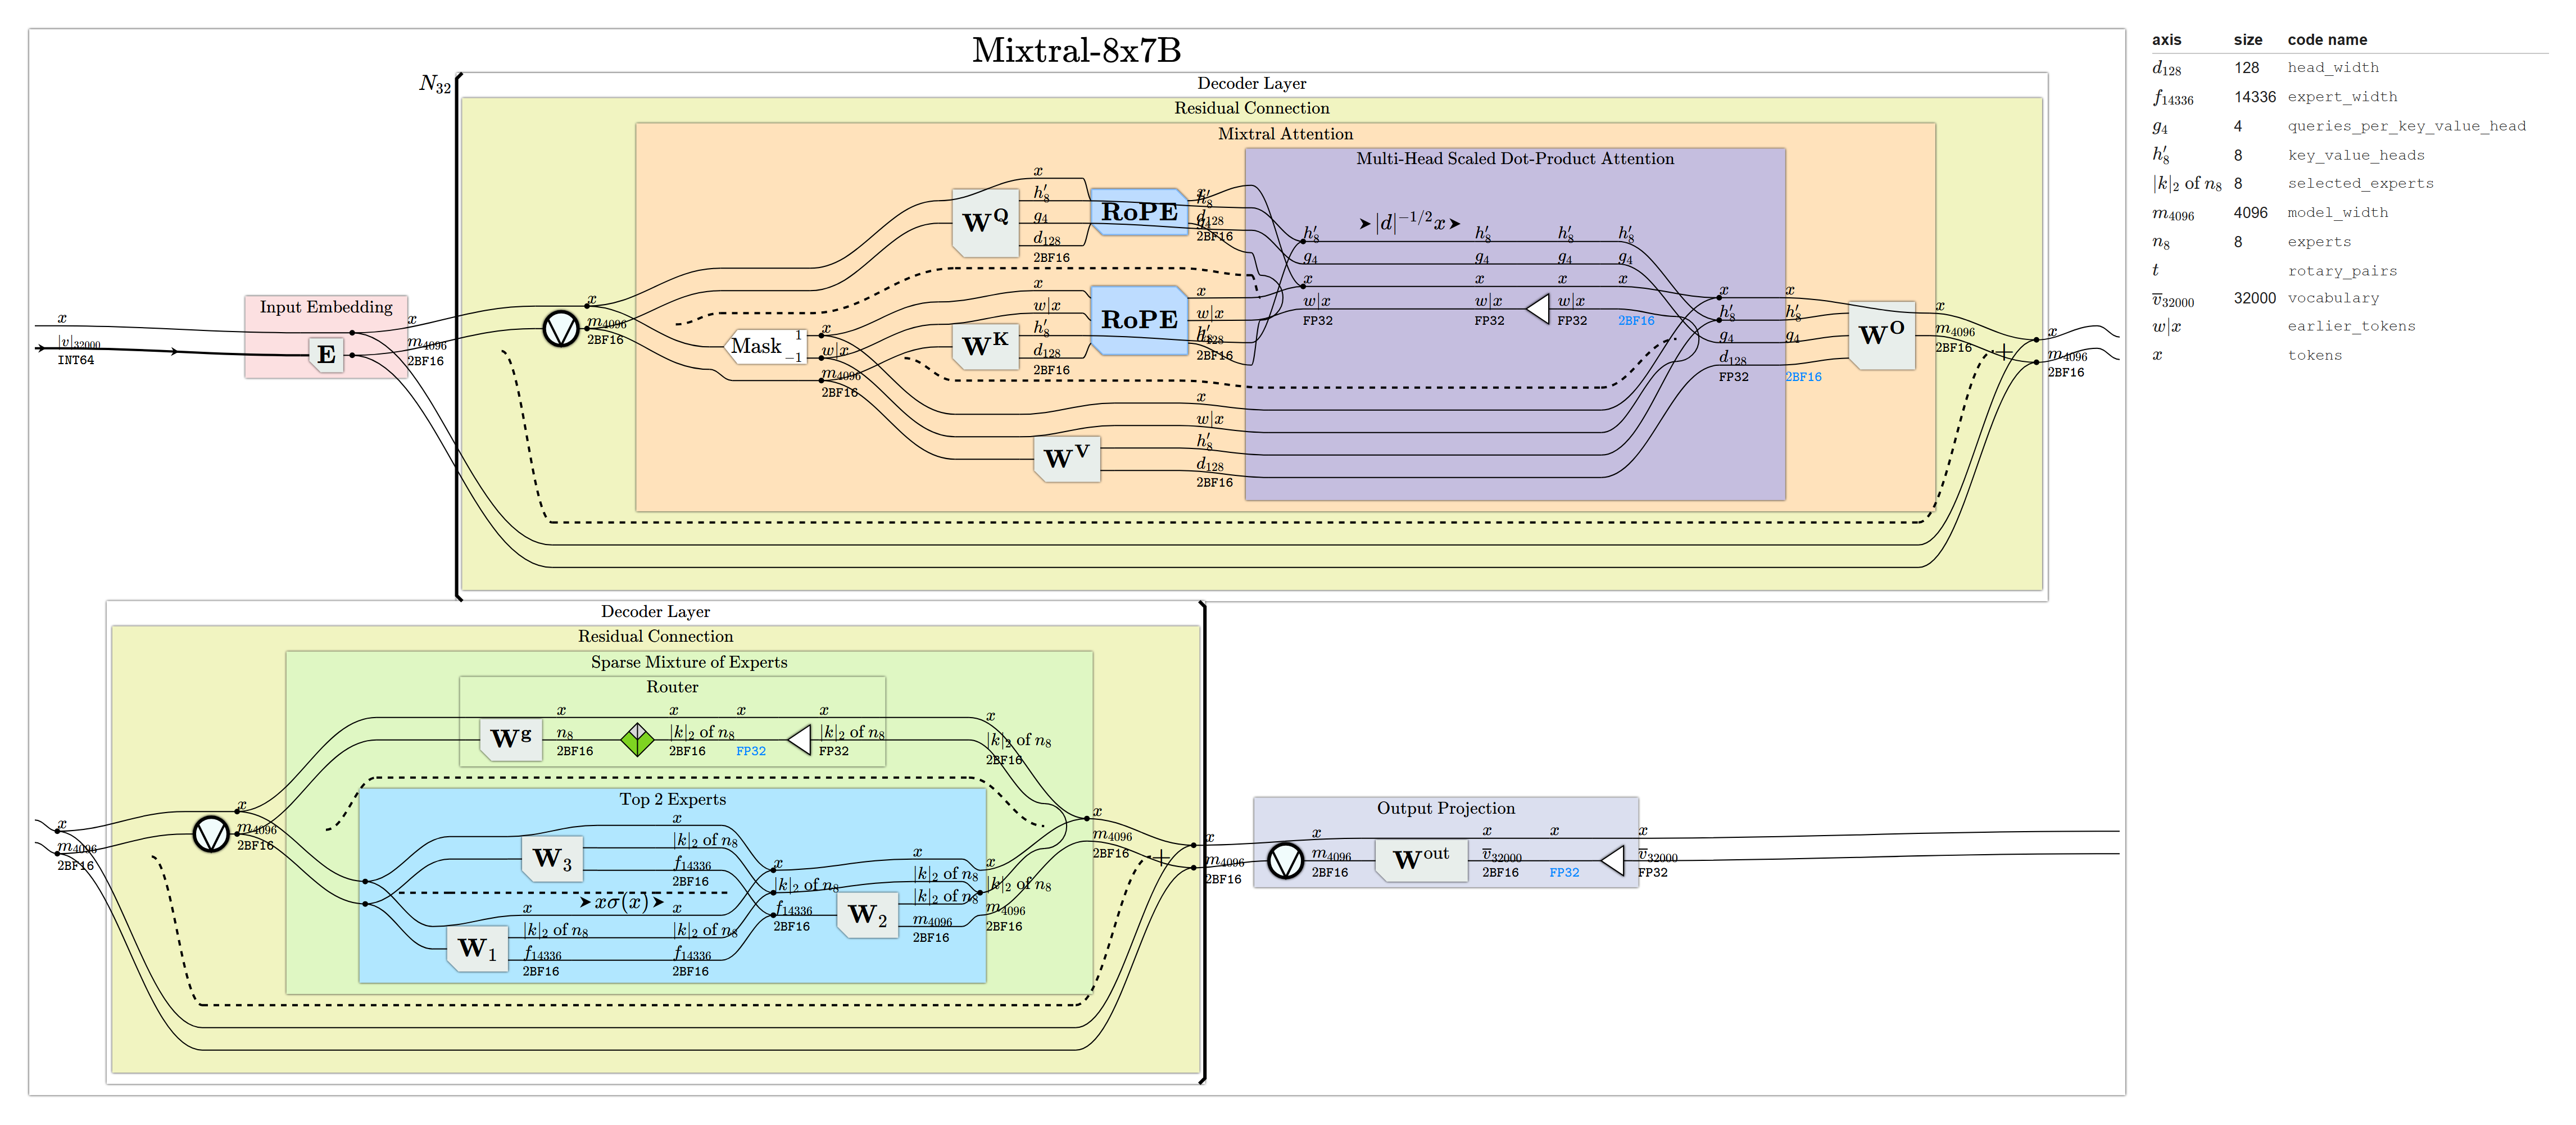

In [7]:
await figures.show(
    quantised_mixtral_8x7b.mixtral_quantised,
    'Mixtral-8x7B at the quantisations of the reference implementation, with every wire '
    'labelled with its format and every cast drawn as the format it writes, in blue.',
    width=1775, sub_blocks=figures.SubBlocks.NO_BODIES, settings=QUANTISED_DIAGRAMS)

The quantised decode form writes nine casts, four reads into FP32 and five roundings to BF16. Each of the two rotary boxes reads its pairs into FP32 and rounds the turned channels to BF16. The box turning the keys has a body of its own in the CausalSlide, because it reads the table of turns at the position of each slot. The router reads its two scores into FP32 and rounds its weights to BF16. The attention kernel rounds the probabilities and its output to BF16, and the logits are read into FP32. Removing every quantisation from the quantised form, together with every cast between two formats of one value, returns the decode form drawn above.

In [8]:
display(Markdown(quantised_mixtral_8x7b.cast_table()))

| read | written | casts written |
|---|---|---|
| BF16 | FP32 | 4 |
| FP32 | BF16 | 5 |

## A Pass of Generation Reads the Keys and the Values of Earlier Tokens from Caches

A pass of generation appends new tokens $x_{\mathrm{new}}$ to the tokens $x_{\mathrm{old}}$ of the earlier passes, and it needs the results of the model at the new tokens alone. The new tokens stand at the positions $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}}$ of the sequence. An operator computed once per token computes the same function at every token, so reading its result at the new tokens is the same as reading its operand there. The read of the new tokens can therefore be carried back from the result of the model through every such operator. At a causal read it becomes the read of position $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}} - i_w$, which reaches earlier tokens. The operand of the causal read is then loaded from a cache holding it at every earlier token, and the new tokens are appended to the cache. `caching.algebra.derive_cached_pass` carries the read through the whole model, places the caches, and rewrites every other operator over the new tokens.

Every operator between the copy that feeds the queries and a causal read is computed once per token, so a cache can stand after any of them. The operators after the cache are then computed at every cached token in every pass. One layer has six placements. The table gives, for each, the values its caches keep per token in one layer, the number of operators computed over the cache, and the time of one layer for one new token after 32,767 earlier ones. The time counts the cache traffic and the linear maps and contractions on an H100 SXM, at its dense BF16 rate of 989 TFLOP/s and its memory bandwidth of 3.35 TB/s, with two bytes per cached value.

In [9]:
display(Markdown(cached_mixtral_8x7b.placement_table()))

| caches | values per token in one layer | operators computed over the cache | µs per layer for one new token |
|---|---|---|---|
| $c_{RoPE}$, $c_{W^{V}}$ | 2,048 | 0 | 50.2 |
| $c_{0}$, $c_{RoPE}$ | 5,120 | 1 | 388.2 |
| $c_{W^{K}}$, $c_{W^{V}}$ | 2,048 | 1 | 50.2 |
| $c_{0}$, $c_{W^{K}}$ | 5,120 | 2 | 388.2 |
| $c_{0}$, $c_{W^{V}}$ | 5,120 | 2 | 388.2 |
| $c_{0}$ | 4,096 | 3 | 646.1 |

The reference caches the keys after the rotary embedding and the values, one of each per key-value head, per earlier token and per layer ([`transformer_layers.py` L66-L81](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L66-L81), [`cache.py` L83-L92](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L83-L92), [L160-L167](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L160-L167)). Every layer caches the whole sequence, because the configuration sets no sliding window ([`cache.py` L13-L15](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L13-L15)). The placement standing on the operands of the two causal reads, with no operator computed over the cache, is the reference cache, and it takes the least time of the six. Caching the keys before the rotation keeps as many values and recomputes the rotation of every cached key in every pass. Caching the normalised state recomputes $W^{K}$ or $W^{V}$ for every cached token, which takes more than seven times as long. The CausalSlide places the cache at the copy, so the pass derived from it caches the normalised state, the last row of the table. The reference caches keep 2,048 values per token in each layer, which is 128 KiB per token over the 32 layers in BF16 and 4 GiB for the 32,768 tokens of the context.

The pass reads the token identifiers of the new tokens and returns their distributions. The two cylinders are the caches, holding the turned keys and the values over the cached tokens followed by the new ones, $x_{\mathrm{old}} + x_{\mathrm{new}}$. Slot $i_w$ of new token $i_{\mathrm{new}}$ reads position $\lvert x_{\mathrm{old}} \rvert + i_{\mathrm{new}} - i_w$ of each cache.

One pass of Mixtral-8x7B over the new tokens, with the keys after the rotary embedding and the values of every earlier token read from the caches.


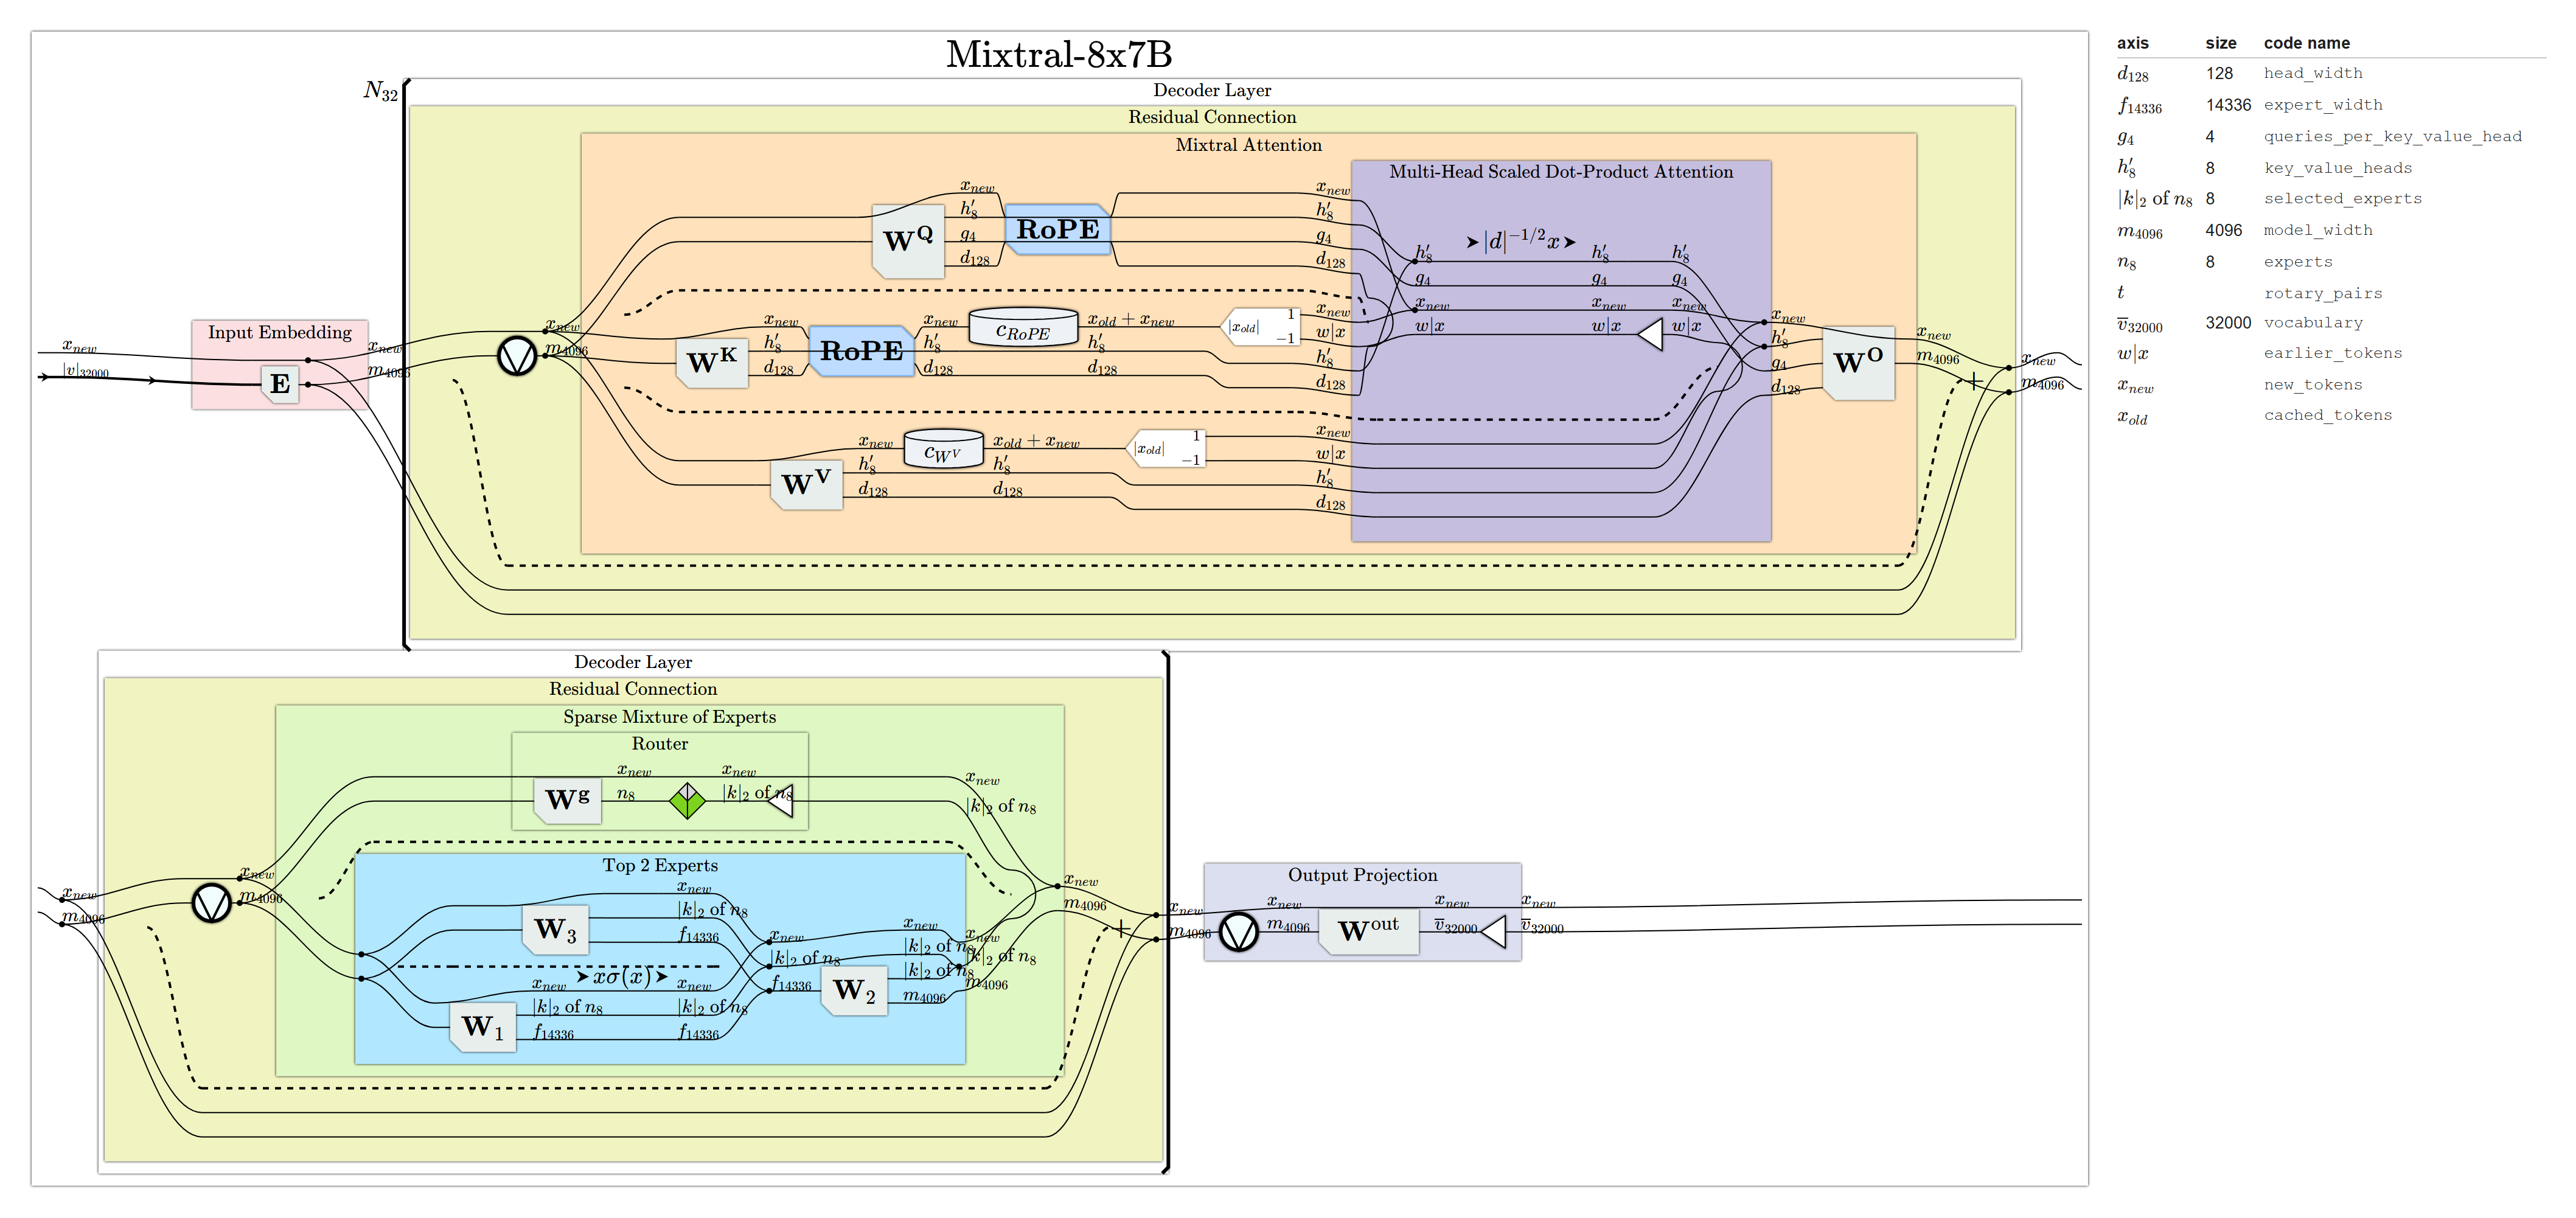

In [10]:
await figures.show(
    cached_mixtral_8x7b.mixtral_cached,
    'One pass of Mixtral-8x7B over the new tokens, with the keys after the rotary '
    'embedding and the values of every earlier token read from the caches.',
    width=1600, sub_blocks=figures.SubBlocks.NO_BODIES, settings=DIAGRAMS)

The quantised pass is derived from the quantised model, so each cache holds its values in the format they arrive in. That format is BF16, the format of the reference cache, which is converted to the format of the model ([`generate.py` L77](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L77), [`cache.py` L186-L191](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L186-L191)). The quantised pass writes seven casts, because the queries and the keys are turned by one body of the rotary embedding. Removing its quantisations returns the pass derived from the model in the real numbers.

## The Interactive Page Holds Four Variants

The page `notebooks/website/output/classic/Mixtral8x7B/index.html` is one file that opens with no server and no network. It holds the decode form and the cached pass, each at the quantisations of the reference implementation and in the real numbers, and the selector above the figure switches between the four. The page opens on the quantised decode form. It derives each unquantised variant in the browser by removing every quantisation and every cast from the quantised variant. The legend lists every axis with its size and a name for it in code. Resting the pointer on a block opens an inspection box with the title of the block, its formula, its description and the released lines expressed by the block. Resting it on a weight states the role and the format of the weight, resting it on a cast states the format read by the cast and the format written by it, and resting it on the views named Mask, Diagonal and New explains the read.

In [11]:
PAGE = dataclasses.replace(
    mixtral_8x7b_page_variants.page_settings(DIAGRAMS),
    page_directory=website_output.CLASSIC_PAGES)
await notebook_diagrams.show_page_variants(
    mixtral_8x7b_page_variants.page_variants(
        quantised_mixtral_8x7b.mixtral_quantised,
        cached_mixtral_8x7b.mixtral_cached_quantised, PAGE),
    'Mixtral-8x7B as one HTML file holding the decode form and the cached pass, each '
    'quantised and unquantised, with the legend of its axes and an inspection box over '
    'every block and every operator.',
    settings=PAGE, slug=mixtral_8x7b_page_variants.SLUG,
    initial=mixtral_8x7b_page_variants.INITIAL_VARIANT)

Mixtral-8x7B as one HTML file holding the decode form and the cached pass, each quantised and unquantised, with the legend of its axes and an inspection box over every block and every operator.


(written to notebooks/website/output/classic/Mixtral8x7B/)


## Differences from the Hand-Drawn Diagram

The figures follow the hand-drawn neural circuit diagram of Mixtral-8x7B at [zardini.mit.edu/diagrams](https://zardini.mit.edu/diagrams/), and they differ from it in these places.

- The diagram draws a window mask of 4096 tokens. The released configuration sets no sliding window ([`config.json` L23](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L23)), so the slot axis of the expression is as long as the sequence. The window of the diagram is the sliding window of Mistral 7B.
- The diagram gives the rotary base as $b = 10000$. The released configuration sets $10^6$ ([L21](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L21)).
- The diagram draws the tokenizer, which reads a string. The expression starts from the token identifiers, because no datatype of the expression holds a string.
- The diagram divides the key-value head index by $g$ with a hexagon. The query projection of the expression produces the query heads as $h'$ groups of $g$ heads, which states the same pairing with no division.
- The diagram reads the keys and the values through the mask after their projections. The figures draw the mask at the copy of the normalised state, in the CausalSlide, which computes the same values.
- The diagram copies the hidden state three times in a gold Copy block, and the expression draws the copies as the wire splitting.
- The diagram names the projections $L^{Q}$, $L^{K}$, $L^{V}$, $L^{O}$ and $L^{g}$, and the expression uses $W^{Q}$, $W^{K}$, $W^{V}$, $W^{O}$ and $W^{g}$, with $W_1$, $W_2$ and $W_3$ for the experts as the released code names them.
- The diagram carries no number formats, and the quantised forms carry the formats of the reference implementation.

## The References

The reference implementation is `mistralai/mistral-inference`, read at commit [`9eaeb91`](https://github.com/mistralai/mistral-inference/tree/9eaeb91c17450e09021b6065a1d5cc69876507c8) on 2026-09-27. The sizes and the format of the weights are those of `mistralai/Mixtral-8x7B-v0.1` on Hugging Face, read at commit [`fc7ac94`](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/tree/fc7ac94680e38d7348cfa806e51218e6273104b0) on 2026-09-27. The attention kernel is read from xformers at the tag [`v0.0.35`](https://github.com/facebookresearch/xformers/tree/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342), the latest release on 2026-09-27, which `xformers>=0.0.24` installs, from PyTorch at the tag [`v2.8.0`](https://github.com/pytorch/pytorch/tree/ba56102387ef21a3b04b357e5b183d48f0afefc7), and from FlashAttention at commit [`979702c`](https://github.com/Dao-AILab/flash-attention/tree/979702c87a8713a8e0a5e9fee122b90d2ef13be5), which PyTorch `v2.8.0` holds as its `third_party/flash-attention` submodule. The paper is arXiv [2401.04088](https://arxiv.org/pdf/2401.04088v1).

| mechanism | released code |
| --- | --- |
| embedding, final norm and output projection | [`transformer.py` L57](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L57), [L78-L79](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L78-L79), [L233-L240](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L233-L240) |
| attention and grouped-query heads | [`transformer_layers.py` L16-L19](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L16-L19), [L31-L93](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L31-L93) |
| rotary embedding | [`rope.py` L6-L23](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/rope.py#L6-L23), [`transformer.py` L108-L120](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L108-L120) |
| RMSNorm | [`transformer_layers.py` L109-L120](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L109-L120) |
| expert | [`transformer_layers.py` L96-L106](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L96-L106) |
| mixture of experts | [`moe.py` L22-L32](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/moe.py#L22-L32), [`transformer_layers.py` L149-L154](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L149-L154) |
| decoder layer | [`transformer_layers.py` L123-L169](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer_layers.py#L123-L169) |
| loading and the format of the model | [`transformer.py` L298-L338](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/transformer.py#L298-L338), [`main.py` L124](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/main.py#L124), [`config.json` L25](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L25) |
| attention kernel | [`dispatch.py` L86-L130](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/dispatch.py#L86-L130), [`flash.py` L50-L82](https://github.com/facebookresearch/xformers/blob/03b91d7d9ff295ae68a320e2e733dd6c2ef8f342/xformers/ops/fmha/flash.py#L50-L82), [`flash_fwd_kernel.h` L303-L436](https://github.com/Dao-AILab/flash-attention/blob/979702c87a8713a8e0a5e9fee122b90d2ef13be5/csrc/flash_attn/src/flash_fwd_kernel.h#L303-L436) |
| cache | [`cache.py` L13-L15](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L13-L15), [L83-L92](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L83-L92), [L160-L191](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/cache.py#L160-L191), [`generate.py` L67-L78](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L67-L78) |
| sampling | [`generate.py` L151-L170](https://github.com/mistralai/mistral-inference/blob/9eaeb91c17450e09021b6065a1d5cc69876507c8/src/mistral_inference/generate.py#L151-L170) |
| sizes | [`config.json` L1-L29](https://huggingface.co/mistralai/Mixtral-8x7B-v0.1/blob/fc7ac94680e38d7348cfa806e51218e6273104b0/config.json#L1-L29) |